# Тестирование веб-приложения Swag Labs

Домашнее задание к уроку «Веб-приложения и их тестирование» (VK Education, курс по ручному тестированию).

**Объект:** [saucedemo.com](https://www.saucedemo.com) — учебный интернет-магазин от Sauce Labs.
**Дата:** 02.10.2026. **Окружение:** Windows 11, Chrome 129, Firefox 131, Edge 129, мобильный режим DevTools.

Все артефакты лежат в `swaglabs_testing.xlsx`: подготовка, чек-лист, тест-кейсы, баг-репорты, итоги. Ноутбук читает книгу и собирает сводку.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

FILE = 'swaglabs_testing.xlsx'
checklist = pd.read_excel(FILE, sheet_name='Чек-лист')
cases = pd.read_excel(FILE, sheet_name='Тест-кейсы')
bugs = pd.read_excel(FILE, sheet_name='Баг-репорты')

# Строки-разделы в чек-листе: название в колонке ID, остальные ячейки пустые
is_section = checklist['Проверка'].isna()
checklist['Раздел'] = checklist['ID'].where(is_section).ffill()
checklist = checklist[checklist['ID'].astype(str).str.startswith('CL')]
print(f'Проверок: {len(checklist)}, тест-кейсов: {len(cases)}, баг-репортов: {len(bugs)}')

Проверок: 45, тест-кейсов: 12, баг-репортов: 14


## 1. Результаты чек-листа по разделам

In [2]:
summary = pd.crosstab(checklist['Раздел'], checklist['Результат'])
summary = summary.reindex(columns=['Pass', 'Fail', 'N/A'], fill_value=0)
summary['Всего'] = summary.sum(axis=1)
summary

Результат,Pass,Fail,N/A,Всего
Раздел,,,,
Авторизация,7,1,0,8
Каталог и карточка товара,3,2,0,5
Корзина,4,2,0,6
Меню,3,2,0,5
Нефункциональные проверки,6,1,0,7
Оформление заказа,5,4,0,9
Сортировка,2,2,0,4


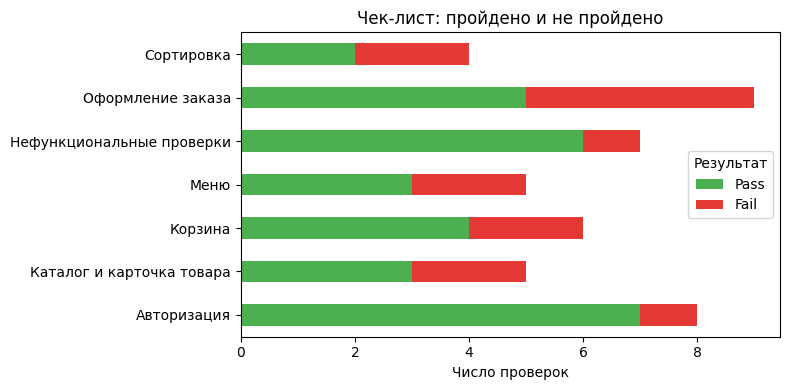

In [3]:
ax = summary[['Pass', 'Fail']].plot.barh(stacked=True, color=['#4CAF50', '#E53935'], figsize=(8, 4))
ax.set_xlabel('Число проверок'); ax.set_ylabel(''); ax.set_title('Чек-лист: пройдено и не пройдено')
plt.tight_layout(); plt.show()

## 2. Функциональное и нефункциональное тестирование

In [4]:
pd.crosstab(checklist['Вид'], checklist['Результат'], margins=True, margins_name='Итого')

Результат,Fail,Pass,Итого
Вид,,,
Нефункц.,2,7,9
Функц.,12,23,35
Итого,14,30,44


## 3. Баги по серьёзности и по пользователям

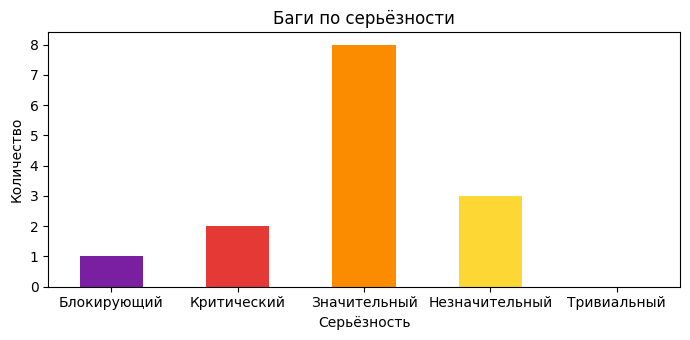

In [5]:
order = ['Блокирующий', 'Критический', 'Значительный', 'Незначительный', 'Тривиальный']
sev = bugs['Серьёзность'].value_counts().reindex(order, fill_value=0)
ax = sev.plot.bar(color=['#7B1FA2', '#E53935', '#FB8C00', '#FDD835', '#90A4AE'], figsize=(7, 3.5))
ax.set_title('Баги по серьёзности'); ax.set_ylabel('Количество'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [6]:
bugs.groupby('Пользователь')['ID'].agg(['count', list]).rename(columns={'count': 'Багов', 'list': 'ID'}).sort_values('Багов', ascending=False)

,Багов,ID
Пользователь,,
problem_user,7,"[BUG-01, BUG-02, BUG-03, BUG-04, BUG-05, BUG-0..."
standard_user,3,"[BUG-07, BUG-08, BUG-09]"
error_user,2,"[BUG-11, BUG-12]"
performance_glitch_user,1,[BUG-10]
visual_user,1,[BUG-13]


## 4. Самые важные дефекты

In [7]:
bugs[bugs['Серьёзность'].isin(['Блокирующий', 'Критический'])][['ID', 'Заголовок', 'Серьёзность', 'Приоритет']]

,ID,Заголовок,Серьёзность,Приоритет
2,BUG-03,problem_user: часть товаров нельзя добавить в ...,Критический,Высокий
4,BUG-05,problem_user: невозможно ввести фамилию при оф...,Блокирующий,Высокий
11,BUG-12,error_user: заказ не завершается кнопкой Finish,Критический,Высокий


## Вывод

Для `standard_user` основной путь покупателя работает. Найдены два дефекта логики, которые затронут любого покупателя: заказ с пустой корзиной (BUG-07) и отсутствие проверки формата в полях заказа (BUG-08).

Остальные учётные записи воспроизводят заложенные в стенд дефекты. Самый серьёзный — BUG-05: `problem_user` не может ввести фамилию и оформить заказ. Кроссбраузерные и адаптивные проверки замечаний не дали.